In [ ]:
import os
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except:
    pass

print("TensorFlow:", tf.__version__)
print("Seed:", SEED)

TensorFlow: 2.20.0
Seed: 42


In [ ]:
(x_train_full, y_train_full), (x_test, y_test) = \
    keras.datasets.cifar10.load_data()

y_train_full = y_train_full.flatten()
y_test = y_test.flatten()

# Normalize
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Fixed split
rng = np.random.RandomState(SEED)
indices = rng.permutation(len(x_train_full))

VAL_SIZE = 5000

val_idx = indices[:VAL_SIZE]
train_idx = indices[VAL_SIZE:]

x_train = x_train_full[train_idx]
y_train = y_train_full[train_idx]

x_val = x_train_full[val_idx]
y_val = y_train_full[val_idx]

print("Train:", x_train.shape)
print("Validation:", x_val.shape)
print("Test:", x_test.shape)

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

Train: (45000, 32, 32, 3)
Validation: (5000, 32, 32, 3)
Test: (10000, 32, 32, 3)


In [ ]:
def build_baseline(
    optimizer="adam",
    learning_rate=0.001,
    dropout=None,
    batch_norm=False,
    l2_value=0.0,
    extra_block=False
):
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)

    model = keras.Sequential()

    model.add(layers.Input(shape=(32, 32, 3)))

    # Block 1
    model.add(
        layers.Conv2D(
            64, (3,3),
            padding="same",
            kernel_regularizer=regularizers.l2(l2_value)
            if l2_value > 0 else None
        )
    )

    if batch_norm:
        model.add(layers.BatchNormalization())

    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2,2)))

    # Block 2
    model.add(
        layers.Conv2D(
            128, (3,3),
            padding="same",
            kernel_regularizer=regularizers.l2(l2_value)
            if l2_value > 0 else None
        )
    )

    if batch_norm:
        model.add(layers.BatchNormalization())

    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2,2)))

    # Block 3
    model.add(
        layers.Conv2D(
            256, (3,3),
            padding="same",
            kernel_regularizer=regularizers.l2(l2_value)
            if l2_value > 0 else None
        )
    )

    if batch_norm:
        model.add(layers.BatchNormalization())

    model.add(layers.ReLU())

    if extra_block:
        model.add(
            layers.Conv2D(
                256, (3,3),
                padding="same",
                activation="relu"
            )
        )

    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Flatten())

    model.add(
        layers.Dense(
            512,
            activation="relu",
            kernel_regularizer=regularizers.l2(l2_value)
            if l2_value > 0 else None
        )
    )

    if dropout is not None:
        model.add(layers.Dropout(dropout))

    model.add(layers.Dense(10, activation="softmax"))

    if optimizer == "adam":
        opt = keras.optimizers.Adam(learning_rate=learning_rate)

    elif optimizer == "sgd":
        opt = keras.optimizers.SGD(
            learning_rate=learning_rate,
            momentum=0.9
        )

    elif optimizer == "rmsprop":
        opt = keras.optimizers.RMSprop(
            learning_rate=learning_rate
        )

    model.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
EPOCHS = 25
BATCH_SIZE = 128

baseline_model = build_baseline(
    optimizer="adam",
    learning_rate=0.001
)

baseline_model.summary()

start = time.time()

baseline_history = baseline_model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

baseline_time = time.time() - start

print("\nTraining time:", baseline_time, "seconds")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,473,610 (9.44 MB)

 Trainable params: 2,473,610 (9.44 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.4764 - loss: 1.4505 - val_accuracy: 0.6084 - val_loss: 1.0861
Epoch 2/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6544 - loss: 0.9907 - val_accuracy: 0.6836 - val_loss: 0.8760
Epoch 3/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7260 - loss: 0.7891 - val_accuracy: 0.7224 - val_loss: 0.7994
Epoch 4/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7708 - loss: 0.6618 - val_accuracy: 0.7228 - val_loss: 0.8272
Epoch 5/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8066 - loss: 0.5553 - val_accuracy: 0.7244 - val_loss: 0.8280
Epoch 6/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8351 - loss: 0.4710 - val_accuracy: 0.6842 - val_loss: 0.9577
Epoch 7/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8611 - loss: 0.3949 - val_accuracy: 0.7182 - val_loss: 0.9222
Epoch 8/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8830 - loss: 0.3282 - val_accu

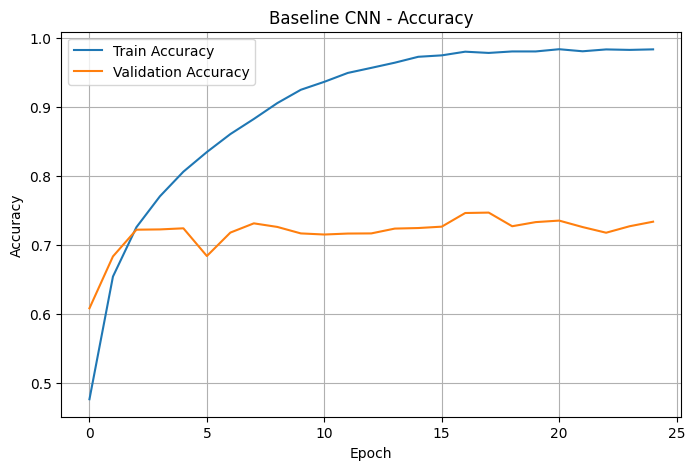

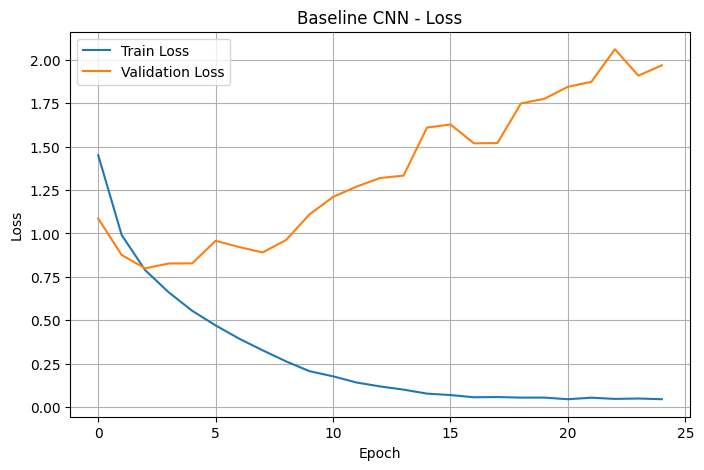

In [ ]:
def plot_history(history, title):
    plt.figure(figsize=(8,5))

    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

    plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(8,5))

    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")

    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()
    plt.show()


plot_history(baseline_history, "Baseline CNN")

In [ ]:
baseline_probs = baseline_model.predict(x_test, verbose=0)
baseline_pred = np.argmax(baseline_probs, axis=1)

baseline_acc = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(
    y_test, baseline_pred, average="macro"
)
baseline_recall = recall_score(
    y_test, baseline_pred, average="macro"
)
baseline_f1 = f1_score(
    y_test, baseline_pred, average="macro"
)

print("Baseline Test Accuracy :", baseline_acc)
print("Precision              :", baseline_precision)
print("Recall                 :", baseline_recall)
print("F1-score               :", baseline_f1)
print("Parameters             :", baseline_model.count_params())
print("Training time          :", baseline_time)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        baseline_pred,
        target_names=class_names
    )
)

Baseline Test Accuracy : 0.7215
Precision              : 0.7279412711563804
Recall                 : 0.7215
F1-score               : 0.7188598640319539
Parameters             : 2473610
Training time          : 132.430415391922

Classification Report:

              precision    recall  f1-score   support

    airplane       0.76      0.77      0.77      1000
  automobile       0.78      0.90      0.83      1000
        bird       0.57      0.70      0.62      1000
         cat       0.62      0.42      0.50      1000
        deer       0.72      0.65      0.68      1000
         dog       0.58      0.71      0.64      1000
        frog       0.88      0.66      0.75      1000
       horse       0.78      0.77      0.78      1000
        ship       0.78      0.88      0.83      1000
       truck       0.82      0.78      0.80      1000

    accuracy                           0.72     10000
   macro avg       0.73      0.72      0.72     10000
weighted avg       0.73      0.72      0.72 

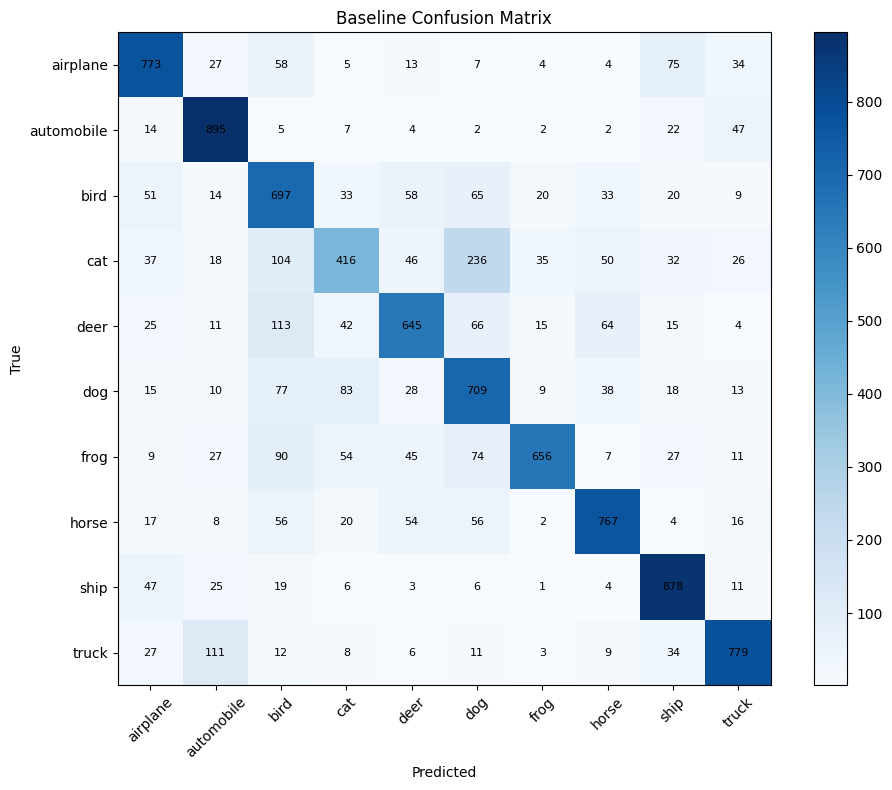

In [ ]:
cm = confusion_matrix(y_test, baseline_pred)

plt.figure(figsize=(10,8))
plt.imshow(cm, cmap="Blues")
plt.title("Baseline Confusion Matrix")
plt.colorbar()

plt.xticks(
    range(10),
    class_names,
    rotation=45
)

plt.yticks(
    range(10),
    class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(10):
    for j in range(10):
        plt.text(
            j, i, cm[i,j],
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()
plt.show()

In [ ]:
def most_confused_pairs(cm, top_n=3):

    temp = cm.copy()

    np.fill_diagonal(temp, 0)

    pairs = []

    for i in range(10):
        for j in range(i + 1, 10):

            confusion = temp[i,j] + temp[j,i]

            pairs.append(
                (
                    confusion,
                    class_names[i],
                    class_names[j]
                )
            )

    pairs.sort(reverse=True)

    return pairs[:top_n]


confused = most_confused_pairs(cm)

print("Most confused class pairs:")

for count, a, b in confused:
    print(f"{a} <-> {b}: {count}")

Most confused class pairs:
cat <-> dog: 319
bird <-> deer: 171
automobile <-> truck: 158


In [ ]:
results = []

def run_experiment(
    name,
    dropout=None,
    batch_norm=False,
    l2_value=0.0,
    optimizer="adam",
    learning_rate=0.001,
    extra_block=False,
    augmentation=None
):

    print("\n" + "="*70)
    print("Experiment:", name)
    print("="*70)

    model = build_baseline(
        optimizer=optimizer,
        learning_rate=learning_rate,
        dropout=dropout,
        batch_norm=batch_norm,
        l2_value=l2_value,
        extra_block=extra_block
    )

    start = time.time()

    if augmentation is None:

        history = model.fit(
            x_train,
            y_train,
            validation_data=(x_val, y_val),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0
        )

    else:

        train_ds = tf.data.Dataset.from_tensor_slices(
            (x_train, y_train)
        )

        train_ds = train_ds.shuffle(
            len(x_train),
            seed=SEED,
            reshuffle_each_iteration=True
        )

        train_ds = train_ds.batch(BATCH_SIZE)

        train_ds = train_ds.map(
            lambda x,y: (augmentation(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE
        )

        train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

        history = model.fit(
            train_ds,
            validation_data=(x_val, y_val),
            epochs=EPOCHS,
            verbose=0
        )

    training_time = time.time() - start

    train_acc = history.history["accuracy"][-1]
    val_acc = history.history["val_accuracy"][-1]

    test_loss, test_acc = model.evaluate(
        x_test,
        y_test,
        verbose=0
    )

    gap = train_acc - val_acc

    results.append({
        "Experiment": name,
        "Train Accuracy": train_acc,
        "Validation Accuracy": val_acc,
        "Test Accuracy": test_acc,
        "Train-Val Gap": gap,
        "Parameters": model.count_params(),
        "Training Time (sec)": training_time
    })

    print("Train Accuracy:", train_acc)
    print("Validation Accuracy:", val_acc)
    print("Test Accuracy:", test_acc)
    print("Train-Val Gap:", gap)
    print("Parameters:", model.count_params())
    print("Time:", training_time)

    return model, history

In [ ]:
dropout_model, dropout_history = run_experiment(
    "Dropout 0.5",
    dropout=0.5
)

bn_model, bn_history = run_experiment(
    "Batch Normalization",
    batch_norm=True
)

l2_model, l2_history = run_experiment(
    "L2 Regularization",
    l2_value=0.0005
)


Experiment: Dropout 0.5
Train Accuracy: 0.9570222496986389
Validation Accuracy: 0.7627999782562256
Test Accuracy: 0.7502999901771545
Train-Val Gap: 0.19422227144241333
Parameters: 2473610
Time: 127.93029999732971

Experiment: Batch Normalization
Train Accuracy: 0.98580002784729
Validation Accuracy: 0.7167999744415283
Test Accuracy: 0.7235000133514404
Train-Val Gap: 0.2690000534057617
Parameters: 2475402
Time: 233.27137446403503

Experiment: L2 Regularization
Train Accuracy: 0.9305777549743652
Validation Accuracy: 0.7429999709129333
Test Accuracy: 0.7353000044822693
Train-Val Gap: 0.18757778406143188
Parameters: 2473610
Time: 130.73880100250244


In [ ]:
light_aug = keras.Sequential([
    layers.RandomFlip("horizontal", seed=SEED)
])


moderate_aug = keras.Sequential([
    layers.RandomFlip("horizontal", seed=SEED),
    layers.RandomRotation(0.05, seed=SEED),
    layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05,
        seed=SEED
    )
])


aggressive_aug = keras.Sequential([
    layers.RandomFlip("horizontal", seed=SEED),
    layers.RandomRotation(0.20, seed=SEED),
    layers.RandomTranslation(
        0.15,
        0.15,
        seed=SEED
    ),
    layers.RandomZoom(0.20, seed=SEED),
    layers.RandomContrast(0.30, seed=SEED)
])

In [ ]:
light_model, light_history = run_experiment(
    "Light Augmentation",
    augmentation=light_aug
)

moderate_model, moderate_history = run_experiment(
    "Moderate Augmentation",
    augmentation=moderate_aug
)

aggressive_model, aggressive_history = run_experiment(
    "Aggressive Augmentation",
    augmentation=aggressive_aug
)


Experiment: Light Augmentation
Train Accuracy: 0.9777110815048218
Validation Accuracy: 0.7979999780654907
Test Accuracy: 0.7849000096321106
Train-Val Gap: 0.17971110343933105
Parameters: 2473610
Time: 190.56829977035522

Experiment: Moderate Augmentation
Train Accuracy: 0.910955548286438
Validation Accuracy: 0.7796000242233276
Test Accuracy: 0.7753999829292297
Train-Val Gap: 0.13135552406311035
Parameters: 2473610
Time: 439.2734978199005

Experiment: Aggressive Augmentation
Train Accuracy: 0.7214666604995728
Validation Accuracy: 0.7084000110626221
Test Accuracy: 0.7006000280380249
Train-Val Gap: 0.013066649436950684
Parameters: 2473610
Time: 598.9739310741425


In [ ]:
sgd_model, sgd_history = run_experiment(
    "SGD + Momentum",
    optimizer="sgd",
    learning_rate=0.001
)

rms_model, rms_history = run_experiment(
    "RMSProp",
    optimizer="rmsprop",
    learning_rate=0.001
)


Experiment: SGD + Momentum
Train Accuracy: 0.6914888620376587
Validation Accuracy: 0.6507999897003174
Test Accuracy: 0.6546000242233276
Train-Val Gap: 0.04068887233734131
Parameters: 2473610
Time: 113.19450354576111

Experiment: RMSProp
Train Accuracy: 0.9870222210884094
Validation Accuracy: 0.7476000189781189
Test Accuracy: 0.7408000230789185
Train-Val Gap: 0.23942220211029053
Parameters: 2473610
Time: 117.89112710952759


In [ ]:
lr_01_model, _ = run_experiment(
    "Adam LR=0.01",
    optimizer="adam",
    learning_rate=0.01
)

lr_0001_model, _ = run_experiment(
    "Adam LR=0.0001",
    optimizer="adam",
    learning_rate=0.0001
)


Experiment: Adam LR=0.01
Train Accuracy: 0.6625999808311462
Validation Accuracy: 0.5267999768257141
Test Accuracy: 0.5224000215530396
Train-Val Gap: 0.13580000400543213
Parameters: 2473610
Time: 124.3136932849884

Experiment: Adam LR=0.0001
Train Accuracy: 0.8424888849258423
Validation Accuracy: 0.7360000014305115
Test Accuracy: 0.7319999933242798
Train-Val Gap: 0.10648888349533081
Parameters: 2473610
Time: 127.06072330474854


In [ ]:
deep_model, deep_history = run_experiment(
    "Extra Convolution Block",
    extra_block=True
)


Experiment: Extra Convolution Block
Train Accuracy: 0.9814444184303284
Validation Accuracy: 0.7396000027656555
Test Accuracy: 0.7315999865531921
Train-Val Gap: 0.24184441566467285
Parameters: 3063690
Time: 153.83227920532227


In [ ]:
baseline_row = {
    "Experiment": "Baseline",
    "Train Accuracy": baseline_history.history["accuracy"][-1],
    "Validation Accuracy": baseline_history.history["val_accuracy"][-1],
    "Test Accuracy": baseline_acc,
    "Train-Val Gap":
        baseline_history.history["accuracy"][-1]
        - baseline_history.history["val_accuracy"][-1],
    "Parameters": baseline_model.count_params(),
    "Training Time (sec)": baseline_time
}

master_df = pd.DataFrame(
    [baseline_row] + results
)

master_df = master_df.sort_values(
    "Test Accuracy",
    ascending=False
)

master_df

,Experiment,Train Accuracy,Validation Accuracy,Test Accuracy,Train-Val Gap,Parameters,Training Time (sec)
1,Dropout 0.5,0.957022,0.7628,0.7503,0.194222,2473610,127.930300
5,RMSProp,0.987022,0.7476,0.7408,0.239422,2473610,117.891127
3,L2 Regularization,0.930578,0.7430,0.7353,0.187578,2473610,130.738801
7,Adam LR=0.0001,0.842489,0.7360,0.7320,0.106489,2473610,127.060723
8,Extra Convolution Block,0.981444,0.7396,0.7316,0.241844,3063690,153.832279
2,Batch Normalization,0.985800,0.7168,0.7235,0.269000,2475402,233.271374
0,Baseline,0.984022,0.7340,0.7215,0.250022,2473610,132.430415
4,SGD + Momentum,0.691489,0.6508,0.6546,0.040689,2473610,113.194504
6,Adam LR=0.01,0.662600,0.5268,0.5224,0.135800,2473610,124.313693


In [ ]:
master_df.to_csv(
    "task1_master_experiment_table.csv",
    index=False
)

print("Saved!")

Saved!


In [ ]:
def build_final_model():

    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)

    model = keras.Sequential([

        layers.Input(shape=(32,32,3)),

        layers.Conv2D(
            64,
            3,
            padding="same"
        ),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(),

        layers.Conv2D(
            128,
            3,
            padding="same"
        ),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(),

        layers.Conv2D(
            256,
            3,
            padding="same"
        ),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(),

        layers.Flatten(),

        layers.Dense(
            512,
            activation="relu"
        ),

        layers.Dropout(0.5),

        layers.Dense(
            10,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


final_model = build_final_model()

final_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,475,402 (9.44 MB)

 Trainable params: 2,474,506 (9.44 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (x_train, y_train)
)

train_ds = train_ds.shuffle(
    len(x_train),
    seed=SEED,
    reshuffle_each_iteration=True
)

train_ds = train_ds.batch(BATCH_SIZE)

train_ds = train_ds.map(
    lambda x,y: (
        moderate_aug(x, training=True),
        y
    ),
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.prefetch(
    tf.data.AUTOTUNE
)

start = time.time()

final_history = final_model.fit(
    train_ds,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    verbose=1
)

final_time = time.time() - start

print(
    "Final model training time:",
    final_time
)

Epoch 1/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.3416 - loss: 1.8943 - val_accuracy: 0.1226 - val_loss: 3.0816
Epoch 2/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.4601 - loss: 1.4727 - val_accuracy: 0.4730 - val_loss: 1.4113
Epoch 3/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.5138 - loss: 1.3367 - val_accuracy: 0.5256 - val_loss: 1.3351
Epoch 4/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.5534 - loss: 1.2449 - val_accuracy: 0.5644 - val_loss: 1.1846
Epoch 5/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.5816 - loss: 1.1767 - val_accuracy: 0.6064 - val_loss: 1.1168
Epoch 6/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.5991 - loss: 1.1290 - val_accuracy: 0.6168 - val_loss: 1.0928
Epoch 7/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.6180 - loss: 1.0884 - val_accuracy: 0.6790 - val_loss: 0.9000
Epoch 8/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.6307 - loss: 1.0466 - 

In [ ]:
final_probs = final_model.predict(
    x_test,
    verbose=0
)

final_pred = np.argmax(
    final_probs,
    axis=1
)

final_acc = accuracy_score(
    y_test,
    final_pred
)

final_precision = precision_score(
    y_test,
    final_pred,
    average="macro"
)

final_recall = recall_score(
    y_test,
    final_pred,
    average="macro"
)

final_f1 = f1_score(
    y_test,
    final_pred,
    average="macro"
)

print("FINAL RESULTS")
print("----------------------")
print("Accuracy :", final_acc)
print("Precision:", final_precision)
print("Recall   :", final_recall)
print("F1 Score :", final_f1)

FINAL RESULTS
----------------------
Accuracy : 0.7318
Precision: 0.7524890276245536
Recall   : 0.7318
F1 Score : 0.7266161799736788


In [ ]:
comparison = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Parameters",
        "Training Time"
    ],

    "Baseline": [
        baseline_acc,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        baseline_model.count_params(),
        baseline_time
    ],

    "Final CNN": [
        final_acc,
        final_precision,
        final_recall,
        final_f1,
        final_model.count_params(),
        final_time
    ]
})

comparison

,Metric,Baseline,Final CNN
0,Accuracy,7.215000e-01,7.318000e-01
1,Precision,7.279413e-01,7.524890e-01
2,Recall,7.215000e-01,7.318000e-01
3,F1 Score,7.188599e-01,7.266162e-01
4,Parameters,2.473610e+06,2.475402e+06
5,Training Time,1.324304e+02,5.772961e+02


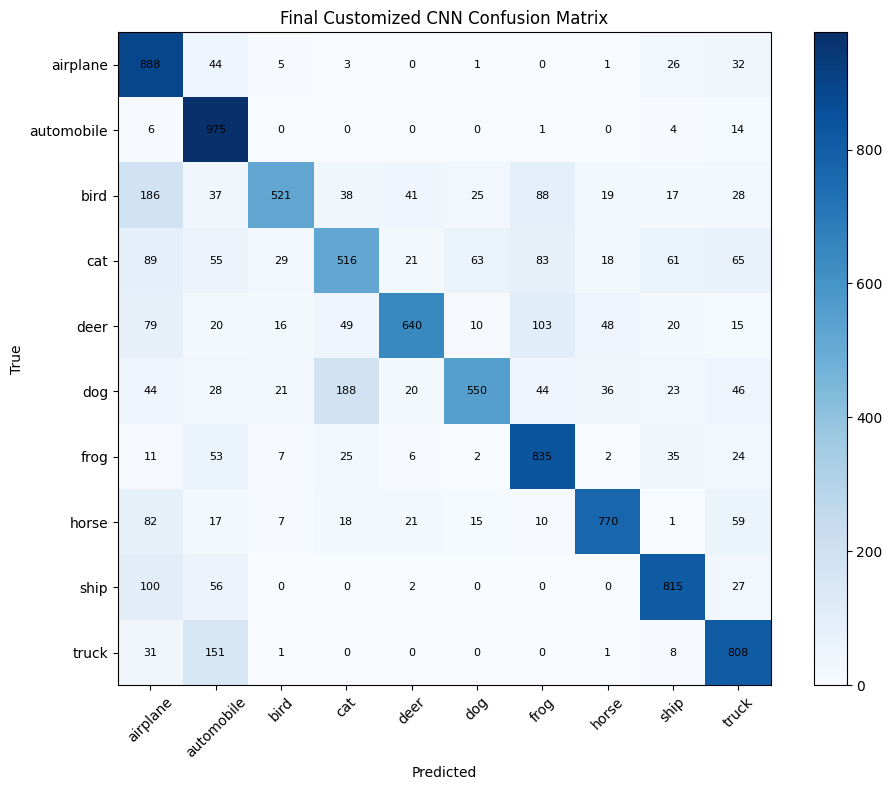

In [ ]:
final_cm = confusion_matrix(
    y_test,
    final_pred
)

plt.figure(figsize=(10,8))

plt.imshow(
    final_cm,
    cmap="Blues"
)

plt.colorbar()

plt.xticks(
    range(10),
    class_names,
    rotation=45
)

plt.yticks(
    range(10),
    class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Final Customized CNN Confusion Matrix")

for i in range(10):
    for j in range(10):

        plt.text(
            j,
            i,
            final_cm[i,j],
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()
plt.show()

In [ ]:
improvement = (
    final_acc - baseline_acc
) * 100

print(
    f"Baseline Accuracy : {baseline_acc*100:.2f}%"
)

print(
    f"Final Accuracy    : {final_acc*100:.2f}%"
)

print(
    f"Improvement       : {improvement:.2f} percentage points"
)

if improvement >= 3:
    print("SUCCESS: >= 3 percentage point improvement")
else:
    print("Target not reached: final model needs improvement.")

Baseline Accuracy : 72.15%
Final Accuracy    : 73.18%
Improvement       : 1.03 percentage points
Target not reached: final model needs improvement.
